# EDA: подготовка панели для DiD

## Назначение

Разведочный анализ структуры данных и пошаговая подготовка фильтрованной панели для difference-in-differences.

## Входные данные

Сырые CSV заявок и гексагонов из `data/raw/`.

## Результаты

Промежуточные таблицы по когортам, контрольной группе и симметричным окнам; материал для выбора порогов фильтрации.

## Статус

Вспомогательный EDA-ноутбук; не входит в основной аналитический пайплайн.


---

## 1. Загрузка библиотек и сырых данных


In [1]:
import pandas as pd

In [2]:
applications = pd.read_csv(
    "../data/raw/application_dataset.csv",
    sep=";",
    parse_dates=[
        "request_timestamp",
        "real_utilization_dttm",
        "planned_start_date",
        "first_success_dttm",
        "start_interval",
    ],
)

hexagons = pd.read_csv(
    "../data/raw/hexagons_dataset.csv",
    parse_dates=["treatment_date"],
)

Беглый просмотр структуры - есть ли ожидаемые столбцы, корректно ли распарсены даты.

In [ ]:
print("Размер таблицы гексагонов:", hexagons.shape)
display(pd.DataFrame({
    "столбец": hexagons.columns,
    "тип данных": hexagons.dtypes.astype(str).to_numpy(),
}))

In [ ]:
print("Размер таблицы заявок:", applications.shape)
display(pd.DataFrame({
    "столбец": applications.columns,
    "тип данных": applications.dtypes.astype(str).to_numpy(),
}))

У `hexagons` есть лишний `Unnamed: 0` - служебный индексный столбец после экспорта в CSV. Убираем.

In [5]:
hexagons.drop(axis=1, columns='Unnamed: 0', inplace=True)

Проверка: столбца больше нет.

In [ ]:
hexagons_summary = pd.DataFrame({
    "непропущенных": hexagons.notna().sum(),
    "уникальных": hexagons.nunique(dropna=True),
})
display(hexagons_summary)

## 2. Размер волн воздействие по датам

Группируем гексагоны по `treatment_date` - сколько гексагонов получили воздействие в каждую волну.

In [7]:
treatments_df = pd.DataFrame(hexagons.groupby("treatment_date").size().sort_index())
treatments_df.rename(columns={0: "number_of_hexes"}, inplace=True)
treatments_df

,number_of_hexes
treatment_date,
2022-07-27,176655
2022-08-12,207665
2022-08-19,1519241
2022-09-22,338043
2022-10-19,1230963


Готовим стиль и строим столбчатую диаграмму - 5 дискретных дат удобно сравнивать барами, а не линией.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette("autumn")
sns.set_style("whitegrid")

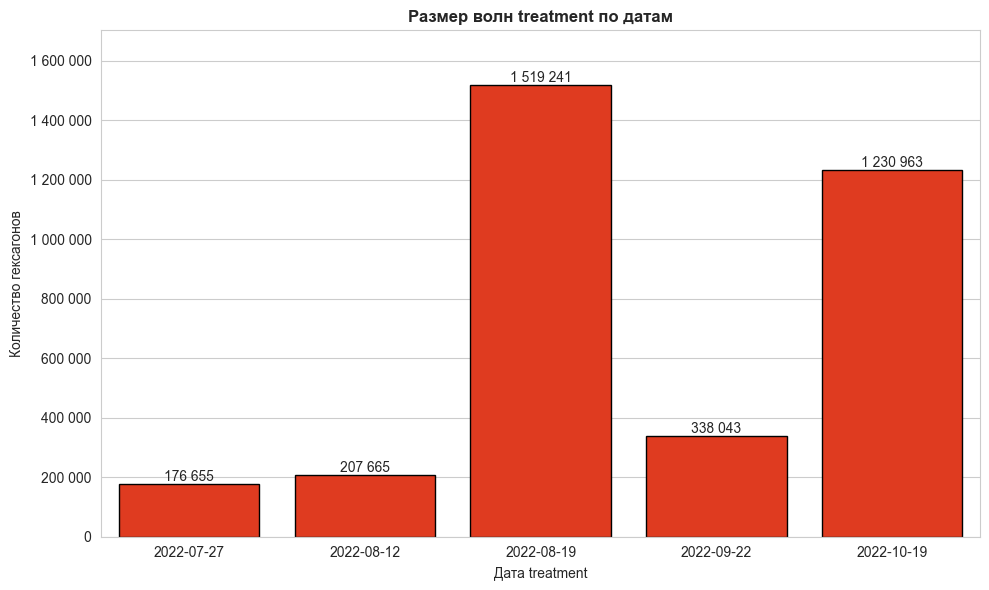

In [9]:
figure, axes = plt.subplots(1, 1, figsize=(10, 6))

plot_df = treatments_df.reset_index()
plot_df["treatment_date"] = plot_df["treatment_date"].dt.strftime("%Y-%m-%d")

bars = sns.barplot(
    ax=axes,
    data=plot_df,
    x="treatment_date",
    y="number_of_hexes",
    edgecolor="black",
)

for bar, value in zip(bars.patches, plot_df["number_of_hexes"]):
    axes.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}".replace(",", " "),
        ha="center",
        va="bottom",
        fontsize=10,
    )

axes.set_xlabel("Дата treatment")
axes.set_ylabel("Количество гексагонов")
axes.set_title("Размер волн treatment по датам", fontweight="bold")
axes.margins(y=0.12)
axes.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " "))
)

figure.tight_layout()
plt.show()

## 3. Контрольная группа

Контрольные гексагоны - те, у которых `treatment_date` пуст (никакого воздействия не оформлялось). Ограничиваемся теми, что встречаются в `applications`, иначе для DiD они бесполезны.

In [10]:
never_treated = hexagons.loc[hexagons.treatment_date.isna(), 'hex']
control_hexes = set(never_treated) & set(applications['hex'])

print(len(control_hexes))

6884


Заявки в этих гексагонах - будущая контрольная панель.

In [ ]:
control_orders = applications[applications["hex"].isin(control_hexes)].copy()
print("Размер контрольной выборки:", control_orders.shape)
display(control_orders[["sch_flg", "meet_flg", "success_flg", "utlz_flg"]].mean().to_frame("доля"))

Распределение заявок на гексагон - общий объём, медиана, минимум и максимум. Разброс огромный (от 1 до 3631 на гексагон), поэтому ниже понадобятся пороги отсечения «тонких» гексагонов.

In [12]:
orders_per_hex = control_orders.groupby('hex').size()
len(control_orders), orders_per_hex.median(), orders_per_hex.min(), orders_per_hex.max()

(329877, 6.0, 1, 3631)

В качестве контрольной группы берём гексагоны с пустым `treatment_date` - они присутствуют в датасете, но воздействие на них не оформлялось. Пересечение с гексагонами, по которым есть заявки, даёт **6884 гексагона** и **329 877 заявок** за весь период наблюдений. Этого достаточно для построения контрфактического состояния: классический DiD, staggered DiD и когортный DiD становятся применимы. Качество контрольной группы внутри неё неоднородно - медианное число заявок на гексагон невелико, поэтому ниже отдельно оценивается распределение и пороги отсечения «тонких» гексагонов.

## 4. Когорты воздействие: оставляем только гексагоны с единственным изменением

Гексагоны с несколькими `treatment_date` в DiD неоднозначны - непонятно, какое именно изменение относить к эффекту. Поэтому работаем только с теми, у которых ровно одна запись о воздействии.

Берём только гексагоны с одним изменением

In [ ]:
single_change = (hexagons.groupby("hex")["treatment_date"]
                 .count()[lambda x: x == 1].index)
print("Гексагонов с одним изменением:", len(single_change))

На каждый такой гексагон у нас одна дата воздействие - выносим её в отдельный справочник `hex -> treatment_date` для последующего join.

In [ ]:
hex_dates = (
    hexagons.loc[hexagons["hex"].isin(single_change), ["hex", "treatment_date"]]
    .drop_duplicates("hex")
    .copy()
)
hex_date_summary = (
    hex_dates.groupby("treatment_date", dropna=False)
    .agg(число_гексагонов=("hex", "nunique"))
    .sort_index()
)
display(hex_date_summary)

Прикрепляем дату воздействие к заявкам и помечаем `post = 1`, если заявка создана не раньше даты изменения.

In [15]:
apps_treated = applications[applications["hex"].isin(single_change)].merge(
    hex_dates, on="hex", how="left"
)

apps_treated["post"] = (
    apps_treated["request_timestamp"] >= apps_treated["treatment_date"]
).astype(int)

Проверка итоговой таблицы - 1 477 440 заявок, 14 столбцов, флаг `post` на месте.

In [16]:
apps_treated

        request_timestamp        type  sch_flg  meet_flg  success_flg  \
0              2022-10-10  Debit Card        1         0            0   
1              2022-08-09  Debit Card        0         0            0   
2              2022-07-15  Debit Card        1         0            0   
3              2022-07-12  Debit Card        1         1            1   
4              2022-05-18  Debit Card        1         0            0   
...                   ...         ...      ...       ...          ...   
1477435        2022-06-15  Debit Card        1         1            1   
1477436        2022-10-12  Debit Card        1         1            1   
1477437        2022-06-15  Debit Card        1         1            1   
1477438        2022-07-07  Debit Card        1         1            1   
1477439        2022-08-04  Debit Card        1         1            1   

         utlz_flg real_utilization_dttm planned_start_date first_success_dttm  \
0               0                   NaT   

## 5. Сводка по когортам: сколько заявок до и после воздействия

Группируем по `(treatment_date, post)`, чтобы увидеть баланс наблюдений в каждой волне. Дополнительно считаем $before\_share = \frac{before}{total}$ - индикатор асимметрии.

In [17]:
summary = (apps_treated
           .groupby(["treatment_date", "post"])
           .size()
           .unstack(fill_value=0)
           .rename(columns={0: "before", 1: "after"}))
summary["total"] = summary["before"] + summary["after"]
summary["before_share"] = (summary["before"] / summary["total"]).round(3)

In [18]:
summary

post            before  after   total  before_share
treatment_date                                     
2022-07-27       19849  12980   32829         0.605
2022-08-12       92125  48619  140744         0.655
2022-08-19      153570  66563  220133         0.698
2022-09-22      340044  60455  400499         0.849
2022-10-19      683082    153  683235         1.000

## 6. Длительность наблюдений до и после каждой даты воздействия

Для каждой когорты считаем, сколько дней наблюдается период «до» и «после». Это вход для решений по исключению когорт и по ширине окна - выводы зафиксированы в markdown-комментариях ниже.

In [19]:
obs_min = applications["request_timestamp"].min()
obs_max = applications["request_timestamp"].max()

print(f"Период наблюдений: {obs_min.date()} - {obs_max.date()}")
print()

for date in sorted(hexagons["treatment_date"].dropna().unique()):
    before = (date - obs_min).days
    after = (obs_max - date).days
    print(f"{pd.Timestamp(date).date()}: до - {before} дн., после - {after} дн.")

Период наблюдений: 2022-04-01 - 2022-10-19

2022-07-27: до - 117 дн., после - 84 дн.
2022-08-12: до - 133 дн., после - 68 дн.
2022-08-19: до - 140 дн., после - 61 дн.
2022-09-22: до - 174 дн., после - 27 дн.
2022-10-19: до - 201 дн., после - 0 дн.


Когорта 2022-10-19 - исключить из анализа. После даты изменения осталось 0 дней наблюдений и 153 заявки. Дата последней когорты совпадает с последним днём наблюдаемого периода. Включение этой когорты в модель даст смещённые оценки после и должно быть исключено на этапе построения панели.

$before\_share = \frac{before}{before + after}$ Иными словами, он показывает насколько асимметрично распределены наблюдения между периодом до и после изменения конфигурации. $before\_share$ сам по себе не является критерием исключения - он является индикатором того, насколько надёжна оценка после. При сильном дисбалансе оценка среднего в периоде после менее устойчива, поскольку основана на меньшем числе наблюдений. Это особенно критично для редких событий - например, конверсий, где и без того мало положительных исходов.

Когорта 2022-09-22 - использовать с оговоркой. 27 дней после изменения, $before\_share = 0.849$. Период после существенно короче периода до. Оценки для этой когорты будут менее устойчивы, чем для ранних когорт.

Дисбаланс before/after нарастает с каждой волной. Это не случайность - чем позже волна изменений, тем меньше остаётся времени для наблюдения периода «после» в рамках датасета. Это системное свойство данных, которое нужно явно зафиксировать в ограничениях.

## 7. Применение фильтров

Исключаем когорты, по которым нет полноценного периода «после». Сейчас это только 2022-10-19 (0 дней после).

In [20]:
EXCLUDED_DATES = ["2022-10-19"]

apps_final = apps_treated.loc[
    ~apps_treated["treatment_date"].isin(pd.to_datetime(EXCLUDED_DATES))
].copy()

Контроль: размер выборки и число оставшихся когорт.

In [21]:
apps_final.shape, apps_final["treatment_date"].nunique()

((794205, 14), 4)

## 8. Симметричные окна вокруг даты воздействия

Для каждой когорты берём `min(до, после)` - окно одинаковой ширины по обе стороны от воздействие. Это устраняет смещение из-за неравных «плеч» и делает сравнение до и после честным.

In [22]:
window_days = {
    pd.Timestamp("2022-07-27"): 84,  # min(117, 84)
    pd.Timestamp("2022-08-12"): 68,  # min(133, 68)
    pd.Timestamp("2022-08-19"): 61,  # min(140, 61)
    pd.Timestamp("2022-09-22"): 27,  # min(174, 27) - спорно, решить отдельно 
}

# здесь без 2022-10-19 - это послденяя когорта, мы ее не смотрим

Считаем расстояние каждой заявки до её даты воздействия в днях (отрицательное - до, положительное - после).

In [ ]:
apps_final.loc[:, "days_from_treatment"] = (
    apps_final["request_timestamp"] - apps_final["treatment_date"]
).dt.days

Оставляем только заявки внутри симметричного окна своей когорты.

In [24]:
def in_window(row):
    w = window_days.get(row["treatment_date"], None)
    if w is None:
        return False
    return -w <= row["days_from_treatment"] <= w

apps_windowed = apps_final[apps_final.apply(in_window, axis=1)]

Финальная сводка по окну - теперь баланс before/after близок к симметричному в каждой когорте.

In [25]:
apps_windowed.groupby(["treatment_date", "post"]).size().unstack()

post,0,1
treatment_date,,
2022-07-27,15539,12980
2022-08-12,49316,48619
2022-08-19,64614,66563
2022-09-22,51009,60455


## 9. Качество контрольной группы - пороги по числу заявок на гексагон

Гексагоны с одной-двумя заявками плохо подходят для контроля: высокая дисперсия, шум вместо сигнала. Смотрим, сколько гексагонов выживает при разных порогах и какая доля заявок при этом сохраняется. Это материал для выбора рабочего порога на следующем этапе.

In [26]:
# Фильтр: оставить только контрольные гексагоны с достаточным числом заявок
hex_order_counts = control_orders.groupby("hex").size()

# Проверить разные пороги
for threshold in [5, 10, 20, 50]:
    surviving = (hex_order_counts >= threshold).sum()
    orders_surviving = hex_order_counts[hex_order_counts >= threshold].sum()
    print(f"Порог ≥{threshold}: {surviving} гексагонов, {orders_surviving} заявок")

Порог ≥5: 3929 гексагонов, 323241 заявок
Порог ≥10: 2525 гексагонов, 313987 заявок
Порог ≥20: 1605 гексагонов, 301548 заявок
Порог ≥50: 825 гексагонов, 277170 заявок


## Вывод

Структура данных согласована с дизайном DiD: есть несколько когорт воздействия, постоянная контрольная группа гексагонов и асимметрия объёмов до/после по датам. Для контроля отбираются гексагоны с достаточным числом заявок (ориентир ≥5); более строгие пороги существенно сокращают выборку. Симметричные окна вокруг даты воздействия строятся для предоценочной диагностики; финальные фильтры задаются в `build_analysis_panel` / `final_empirical_recalculation.ipynb`.
